<div style="background-color:rgb(255, 255, 200);">
    
<p style="font-size: 32px; font-weight: bold;">Kernel PCA</p>


**File name: kernel-pca.ipynb**

**Author: Du Huynh**<br>
**May 3, 2026**

This small Python Jupyter Notebook file illustrates the concept of dimensionality reduction applied to the elevated feature space and also how to do so **implicitly** using the `KernelPCA` class of Scikit-Learn. This allows a simple linear classifier, such as `LogisticRegression`, to achieve great classification accuracy when the original input data are not linearly separable.

</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import sklearn

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA, KernelPCA
from sklearn.linear_model import LogisticRegression

In [2]:
print(f'\033[1msklearn version: {sklearn.__version__}\033[0m')

sklearn version: 1.6.1


# Some helper functions

In [3]:
def save_fig(fig_id, tight_layout=True, fig_extension="pdf", resolution=300):
    filename = f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout(rect=(-0.01, -0.01, 1.01, 1.01))
    plt.savefig(filename, format=fig_extension, dpi=resolution)

def plot_data(X_train, y_train, X_test, y_test, filename=""):
    _, axes = plt.subplots(ncols=2, sharey=True, figsize=(6,3))
    for ax,XX,yy,title in zip(axes, [X_train,X_test], [y_train,y_test],
                        ["Training data", "Testing data"]):
        ax.scatter(XX[:,0], XX[:,1], c=yy, alpha=0.6)
        ax.set_ylabel("Feature #1")
        ax.set_xlabel("Feature #0")
        ax.grid('on')
        ax.set_title(title)
    if filename != "":
        save_fig(filename)
        print('Figure saved to', filename)
    plt.show()


# Synthesizing a dataset that is not linearly separable

(750, 2) (750,) (250, 2) (250,)


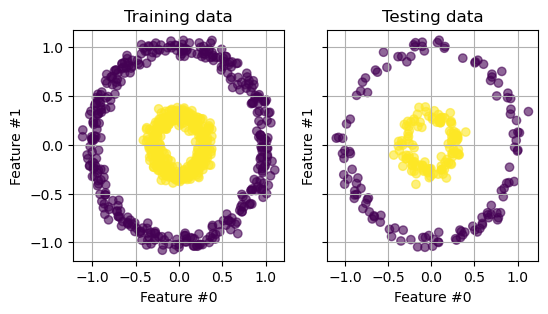

In [4]:
X, y = make_circles(n_samples=1_000, factor=0.3, noise=0.05, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

plot_data(X_train, y_train, X_test, y_test)

# Computing polynomial features then PCA?

Now try elevating the *2D* features to a higher dimensional space and then back down to *5D* using PCA. In the code below, the original *2D* features are elevated to a **21**-dimensional space using the `PolynomialFeatures` class, with the degree of the polynomial set to $5$.

In [5]:
poly = PolynomialFeatures(degree = 5)
Xpoly_train = poly.fit_transform(X_train)
Xpoly_test = poly.transform(X_test)
print('Xpoly_train.shape =  ', Xpoly_train.shape)  # the polynomial features have dimension 21

Xpoly_train.shape =   (750, 21)


## Using all the features (i.e., without applying PCA)

In [6]:
lr_clf = LogisticRegression()
lr_clf.fit(Xpoly_train, y_train)

print('Linear regression classifier:')
print(f'Training accuracy = {lr_clf.score(Xpoly_train, y_train):1.4f}')
print(f'Testing accuracy  = {lr_clf.score(Xpoly_test, y_test):1.4f}')

Linear regression classifier:
Training accuracy = 1.0000
Testing accuracy  = 1.0000


## Now try truncating down to, say, 5-dimensions, using PCA

We expect that there might be a slight drop of training and testing accuracy. However, dropping from **21**D down to **5**D is a huge saving of disk space for data storage. The amount of information that we sacrifice is less than 10%, as shown below.

Note that from the two subplots, we can see that using just 2 dimensions would not be enough. However, using 5 dimensions (unfortunately, we can't visualize them easily) should do the job pretty well.

Xpoly5D_train.shape = (750, 5)
Variances of the 5 PCA features = [0.30761142 0.29855071 0.14299344 0.10322657 0.05375122]
Total variance of the 5 PCA featues  = 90.613%
Variance sacrificed (lost) after PCA =  9.387%



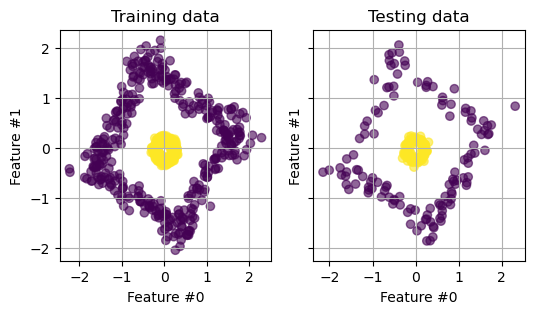

Logistic regression classifier:
Training accuracy = 1.0000
Testing accuracy  = 1.0000


In [7]:
pca = PCA(n_components=5)
Xpoly5D_train = pca.fit_transform(Xpoly_train)
Xpoly5D_test = pca.transform(Xpoly_test)
print('Xpoly5D_train.shape =', Xpoly5D_train.shape)
print('Variances of the 5 PCA features =', pca.explained_variance_ratio_)
print(f'Total variance of the 5 PCA featues  = {100*np.sum(pca.explained_variance_ratio_):6.3f}%')
print(f'Variance sacrificed (lost) after PCA = {100*(1-np.sum(pca.explained_variance_ratio_)):6.3f}%')
print()

plot_data(Xpoly5D_train, y_train, Xpoly5D_test, y_test)

lr_clf.fit(Xpoly5D_train, y_train)

print('Logistic regression classifier:')
print(f'Training accuracy = {lr_clf.score(Xpoly5D_train, y_train):1.4f}')
print(f'Testing accuracy  = {lr_clf.score(Xpoly5D_test, y_test):1.4f}')

# How about using a more powerful kernel -- the RBF?

For the `PolynomialFeatures` code above, we explicitly elevate the features to a higher dimensional space and then we apply the PCA for dimensionality reduction. This explicit feature elevation process is not possible for the RBF kernel as the *higher dimensional space* in this case has infinite dimensions. However, we can do so implicitly by combining the kernel operation and the PCA operation together, using the `KernelPCA` class.

## Truncating down to 2 dimensions
Since we believe that the RBF kernel should work better than the Polynomial kernel, let's try truncating the dimension down to **2**.

In [8]:
kernel_pca = KernelPCA(n_components=2, kernel="rbf", 
                       gamma=10, fit_inverse_transform=True, alpha=0.1)
Xrbf2D_train = kernel_pca.fit_transform(X_train)
Xrbf2D_test = kernel_pca.transform(X_test)

print('Xrbf2D_train.shape =', Xrbf2D_train.shape)

Xrbf2D_train.shape = (750, 2)


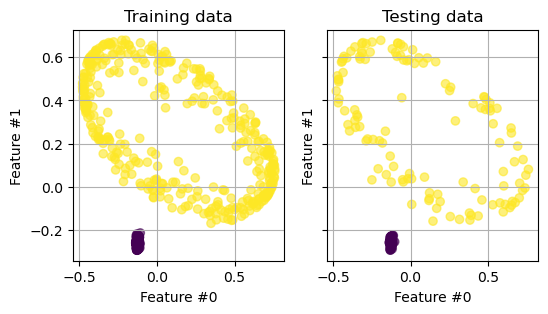

Logistic regression classifier:
Training accuracy = 1.0000
Testing accuracy  = 0.9880


In [9]:
plot_data(Xrbf2D_train, y_train, Xrbf2D_test, y_test)

lr_clf.fit(Xrbf2D_train, y_train)
print('Logistic regression classifier:')
print(f'Training accuracy = {lr_clf.score(Xrbf2D_train, y_train):1.4f}')
print(f'Testing accuracy  = {lr_clf.score(Xrbf2D_test, y_test):1.4f}')

### Let's try the LinearSVC classifier...

It is not clear why the test accuracy is not 100% when the illustration shows that the two classes are linearly separable. Let's try the `LinearSVC` classifier -- it should work better than the `LogisticRegression` classifier.

In [10]:
from sklearn.svm import LinearSVC

lsvc = LinearSVC()
lsvc.fit(Xrbf2D_train, y_train)

print('Linear SVC classifier:')
print(f'Training accuracy = {lsvc.score(Xrbf2D_train, y_train):1.4f}')
print(f'Testing accuracy  = {lsvc.score(Xrbf2D_test, y_test):1.4f}')

Linear SVC classifier:
Training accuracy = 1.0000
Testing accuracy  = 1.0000
